In [1]:
!pip install -r requirements.txt

In [2]:
import kagglehub
# path = kagglehub.dataset_download("jessicali9530/lfw-dataset")
path = kagglehub.dataset_download("jangedoo/utkface-new")

/home/e20210007813/Bureau/ProjImage/face_filters/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 331M/331M [00:14<00:00, 24.2MB/s] 

Extracting files...


In [3]:
import cv2
import os

In [4]:
# Load face detection classifier
face_classifier = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

In [5]:
image_size = 128
images = []
ages = []

In [6]:
def preprocess_image(img_path):
    img = cv2.imread(img_path)
    if img is None:
        print(f"Warning: Could not load image {img_path}. Skipping.")
        return []

    grey_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_classifier.detectMultiScale(
        grey_img, scaleFactor=1.1, minNeighbors=5, minSize=(120, 120)
    )

    crops = []
    for (x, y, w, h) in faces:
        x_max = min(img.shape[1], x + w)
        y_max = min(img.shape[0], y + h)
        x = max(0, x)
        y = max(0, y)

        if w <= 0 or h <= 0:
            continue

        im_cropped = img[y:y_max, x:x_max]
        if im_cropped.size == 0:
            continue

        im_cropped = cv2.cvtColor(im_cropped, cv2.COLOR_BGR2RGB)
        im_cropped = cv2.resize(im_cropped, (image_size, image_size))
        im_cropped = im_cropped.astype("float32") / 255.0
        crops.append(im_cropped)

    return crops

In [ ]:
i = 0
numImg = 25000
for root, dirs, files in os.walk(path):
    for file in files:
        if i >= numImg:
            break
        if file.endswith(".jpg"):
            img_path = os.path.join(root, file)
            processed_crops = preprocess_image(img_path)
            age = int(file.split("_")[0])
            if len(processed_crops) == 0:
                continue
            for crop in processed_crops:
                images.append(crop)
                normalized_age = age / 116
                ages.append(normalized_age)
                i += 1
                if i >= numImg:
                    break

In [8]:
!pip show tensorflow

Name: tensorflow
Version: 2.20.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: /home/e20210007813/Bureau/ProjImage/face_filters/.venv/lib/python3.10/site-packages
Requires: absl-py, astunparse, flatbuffers, gast, google_pasta, grpcio, h5py, keras, libclang, ml_dtypes, numpy, opt_einsum, packaging, protobuf, requests, setuptools, six, tensorboard, termcolor, typing_extensions, wrapt
Required-by: 


In [9]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input

2025-12-01 12:01:29.078614: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-01 12:01:33.343222: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-01 12:01:53.568181: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
Matplotlib is building the font cache; this may take a moment.


In [10]:
from sklearn.model_selection import train_test_split
import numpy as np

x_train, x_test, x_train_ages, x_test_ages = train_test_split(
    images, ages, test_size=0.2, random_state=42
)

x_train = np.array(x_train, dtype=np.float32)
x_test = np.array(x_test, dtype=np.float32)

x_train_ages = np.array(x_train_ages, dtype=np.float32).reshape(-1,1)
x_test_ages = np.array(x_test_ages, dtype=np.float32).reshape(-1,1)

# Crear datasets de tf.data
batch_size = 32

train_dataset = tf.data.Dataset.from_tensor_slices((x_train, x_train_ages))
train_dataset = train_dataset.shuffle(buffer_size=1024).batch(batch_size)

val_dataset = tf.data.Dataset.from_tensor_slices((x_test, x_test_ages))
val_dataset = val_dataset.batch(batch_size)

print(x_train.shape, x_train_ages.shape)
print(x_test.shape, x_test_ages.shape)


(800, 128, 128, 3) (800, 1)
(200, 128, 128, 3) (200, 1)


I0000 00:00:1764586933.719523   76100 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 7446 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080, pci bus id: 0000:01:00.0, compute capability: 8.6


In [11]:

from keras.saving import register_keras_serializable

def residual_block(x, filters, strides=1):
    shortcut = x
    if strides != 1 or x.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=strides, padding="same")(shortcut)
    x = layers.Conv2D(filters, 3, strides=strides, padding="same", activation="relu")(x)
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.Add()([x, shortcut])
    x = layers.Activation("relu")(x)
    return x

def build_encoder(latent_dim):
    encoder_inputs = Input(shape=(128,128,3))
    age_input = Input(shape=(1,))

    x = layers.Conv2D(16, 3, strides=2, padding="same", activation="relu")(encoder_inputs)
    x = residual_block(x, 32, strides=2)
    x = residual_block(x, 64, strides=2)
    x = residual_block(x, 128, strides=2)

    x_flat = layers.Flatten()(x)
    x_flat = layers.Dense(256, activation="relu")(x_flat)

    # Concatenar edad
    age_encoded = layers.Dense(32, activation="relu")(age_input)
    x_flat = layers.Concatenate()([x_flat, age_encoded])

    z_mean = layers.Dense(latent_dim)(x_flat)
    z_log_var = layers.Dense(latent_dim)(x_flat)

    @register_keras_serializable()
    def sampling(args):
        mean, log_var = args
        epsilon = tf.random.normal(shape=tf.shape(mean))
        return mean + tf.exp(0.5 * log_var) * epsilon

    z = layers.Lambda(sampling)([z_mean, z_log_var])

    return Model([encoder_inputs, age_input], [z_mean, z_log_var, z], name="encoder")



In [12]:
def build_decoder(latent_dim):
    z_inputs = Input(shape=(latent_dim,))
    age_input = Input(shape=(1,))

    # Procesar edad
    age_encoded = layers.Dense(32, activation="relu")(age_input)
    age_encoded = layers.Reshape((1,1,32))(age_encoded)
    age_encoded = layers.Lambda(lambda t: tf.tile(t, [1, 8, 8, 1]))(age_encoded)

    # Reconstrucción desde el latente
    x = layers.Dense(8*8*128, activation="relu")(z_inputs)
    x = layers.Reshape((8,8,128))(x)

    # Concatenar información de edad
    x = layers.Concatenate()([x, age_encoded])

    # Upsampling progresivo sin skips
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.UpSampling2D()(x)

    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.UpSampling2D()(x)

    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.UpSampling2D()(x)

    x = layers.Conv2D(16, 3, padding="same", activation="relu")(x)
    x = layers.UpSampling2D()(x)

    outputs = layers.Conv2D(3, 3, activation="sigmoid", padding="same")(x)

    # Predicción de edad
    flat = layers.Flatten()(x)
    age_pred = layers.Dense(1, activation="linear", name="age_pred")(flat)

    return Model([z_inputs, age_input], [outputs, age_pred], name="decoder")



In [13]:
def build_discriminator():
    """Lighter discriminator with dropout"""
    model = keras.Sequential([
        layers.InputLayer(input_shape=(128, 128, 3)),
        
        # Block 1
        layers.Conv2D(64, (4, 4), strides=2, padding='same'),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),
        
        # Block 2
        layers.Conv2D(128, (4, 4), strides=2, padding='same'),
        layers.BatchNormalization(),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),
        
        # Block 3
        layers.Conv2D(256, (4, 4), strides=2, padding='same'),
        layers.BatchNormalization(),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),
        
        # Block 4
        layers.Conv2D(512, (4, 4), strides=2, padding='same'),
        layers.BatchNormalization(),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),
        
        # Output
        layers.Flatten(),
        layers.Dense(1)  # No sigmoid, use from_logits=True
    ])
    return model

In [14]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

from keras_facenet import FaceNet
identity_model = FaceNet().model
identity_model.trainable = False

recon_weight = 1.0
kl_weight = 0.001
p_weight = 0.0001
identity_weight = 0.01
age_weight = 0.1
gan_weight = 0.1

# --- Preparar modelo VGG para perceptual loss ---
vgg = VGG16(include_top=False, weights='imagenet', input_shape=(128,128,3))
vgg.trainable = False
layer_names = ['block3_conv3', 'block4_conv3']
vgg_outputs = [vgg.get_layer(name).output for name in layer_names]
vgg_model = Model(inputs=vgg.input, outputs=vgg_outputs)

def perceptual_loss(x_true, x_pred):
    # VGG espera imágenes en [0,255], actualmente tus imágenes están en [0,1]
    x_true_pp = preprocess_input(x_true * 255.0)
    x_pred_pp = preprocess_input(x_pred * 255.0)
    
    features_true = vgg_model(x_true_pp)
    features_pred = vgg_model(x_pred_pp)
    
    loss = 0
    for f_true, f_pred in zip(features_true, features_pred):
        loss += tf.reduce_mean(tf.square(f_true - f_pred))
    return loss

def identity_loss(x_true, x_pred):
    # FaceNet espera 160x160 y [0,255]
    x_true_resized = tf.image.resize(x_true, (160, 160)) * 255.0
    x_pred_resized = tf.image.resize(x_pred, (160, 160)) * 255.0

    emb_true = identity_model(x_true_resized)
    emb_pred = identity_model(x_pred_resized)

    return tf.reduce_mean(tf.square(emb_true - emb_pred))

def age_loss(y_true_age, y_pred_age):
    return tf.reduce_mean(tf.square(y_true_age - y_pred_age))

bce = tf.keras.losses.BinaryCrossentropy(from_logits=True)
def gan_loss(disc_real, disc_fake):
    real_loss = bce(tf.ones_like(disc_real), disc_real)
    fake_loss = bce(tf.zeros_like(disc_fake), disc_fake)
    return real_loss + fake_loss

In [15]:
class VAE(tf.keras.Model):
    def __init__(self, encoder, decoder, discriminator):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.discriminator = discriminator

    def compile(self, gen_optimizer, disc_optimizer):
        super().compile()
        self.gen_optimizer = gen_optimizer
        self.disc_optimizer = disc_optimizer
        self.bce = tf.keras.losses.BinaryCrossentropy(from_logits=True)

    def train_step(self, data):
        x, age_input = data
        batch_size = tf.shape(x)[0]
        
        # ============================================================
        # 1) TRAIN VAE (Encoder + Decoder) - Generate fake images
        # ============================================================
        with tf.GradientTape() as vae_tape:
            z_mean, z_log_var, z = self.encoder([x, age_input], training=True)
            reconstruction, age_pred = self.decoder([z, age_input], training=True)
            
            # Reconstruction loss (MAE + SSIM)
            mae = tf.reduce_mean(tf.abs(x - reconstruction), axis=[1,2,3])
            ssim = tf.clip_by_value(tf.image.ssim(x, reconstruction, max_val=1.0), 0.0, 1.0)
            recon_loss = tf.reduce_mean(mae + 0.5*(1-ssim))
            
            # KL loss
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
            )
            
            # Other losses
            p_loss = perceptual_loss(x, reconstruction)
            id_loss = identity_loss(x, reconstruction)
            age_loss_value = age_loss(age_input, age_pred)
            
            # GAN loss for generator: fool discriminator
            disc_fake = self.discriminator(reconstruction, training=False)
            valid_labels = tf.ones_like(disc_fake)
            gan_loss_value = self.bce(valid_labels, disc_fake)
            
            # Total VAE loss (REDUCED WEIGHTS)
            vae_loss = (
                recon_loss +                        # Keep at 1.0
                0.001 * kl_loss +                   # Reduced from 1.0
                0.0001 * p_loss +                   # Reduced from 0.5
                0.01 * id_loss +                    # Reduced from 0.2
                0.1 * age_loss_value +              # Reduced from 0.2
                0.1 * gan_loss_value                # Added GAN component
            )
        
        # Update VAE
        vae_vars = self.encoder.trainable_weights + self.decoder.trainable_weights
        vae_grads = vae_tape.gradient(vae_loss, vae_vars)
        self.gen_optimizer.apply_gradients(zip(vae_grads, vae_vars))
        
        # ============================================================
        # 2) TRAIN DISCRIMINATOR - Use freshly generated images
        # ============================================================
        # Generate NEW fake images with updated generator
        z_mean, z_log_var, z = self.encoder([x, age_input], training=False)
        fake_imgs, _ = self.decoder([z, age_input], training=False)
        
        with tf.GradientTape() as disc_tape:
            # Real images
            disc_real = self.discriminator(x, training=True)
            # Fake images (detached from generator)
            disc_fake = self.discriminator(tf.stop_gradient(fake_imgs), training=True)
            
            # Labels with label smoothing
            real_labels = tf.ones((batch_size, 1)) * 0.9  # 0.9 instead of 1.0
            fake_labels = tf.zeros((batch_size, 1)) + 0.1  # 0.1 instead of 0.0
            
            d_loss_real = self.bce(real_labels, disc_real)
            d_loss_fake = self.bce(fake_labels, disc_fake)
            disc_loss = d_loss_real + d_loss_fake
        
        # Update discriminator
        disc_grads = disc_tape.gradient(disc_loss, self.discriminator.trainable_weights)
        self.disc_optimizer.apply_gradients(
            zip(disc_grads, self.discriminator.trainable_weights)
        )
        
        return {
            "loss": vae_loss,
            "vae_loss": vae_loss,
            "gan_loss": gan_loss_value,
            "disc_loss": disc_loss,
            "reconstruction_loss": recon_loss,
            "kl_loss": kl_loss,
            "perceptual_loss": p_loss,
            "identity_loss": id_loss,
            "age_loss": age_loss_value
        }

    def test_step(self, data):
        x, age_input = data

        z_mean, z_log_var, z = self.encoder([x, age_input], training=False)
        reconstruction, age_pred = self.decoder([z, age_input], training=False)

        # Recon losses
        mae = tf.reduce_mean(tf.abs(x - reconstruction), axis=[1,2,3])
        ssim = tf.clip_by_value(tf.image.ssim(x, reconstruction, max_val=1.0), 0.0, 1.0)
        recon_loss = tf.reduce_mean(mae + 0.5*(1-ssim))
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
        )

        p_loss = perceptual_loss(x, reconstruction)
        id_loss = identity_loss(x, reconstruction)
        age_loss_value = age_loss(age_input, age_pred)

        vae_loss = (
            recon_weight * recon_loss +
            kl_weight * kl_loss +
            p_weight * p_loss +
            identity_weight * id_loss +
            age_weight * age_loss_value
        )

        disc_real = self.discriminator(x, training=False)
        disc_fake = self.discriminator(reconstruction, training=False)
        gan_loss_value = gan_loss(disc_real, disc_fake)

        total_loss = vae_loss + gan_weight * gan_loss_value

        return {
            "loss": total_loss,
            "vae_loss": vae_loss,
            "gan_loss": gan_loss_value,
            "reconstruction_loss": recon_loss,
            "kl_loss": kl_loss,
            "perceptual_loss": p_loss,
            "identity_loss": id_loss,
            "age_loss": age_loss_value
        }

In [16]:
latent_dim = 128

encoder = build_encoder(latent_dim)
decoder = build_decoder(latent_dim)
discriminator = build_discriminator()

/home/e20210007813/Bureau/ProjImage/face_filters/.venv/lib/python3.10/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [17]:
vae = VAE(encoder, decoder, discriminator)
vae.compile(
    gen_optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    disc_optimizer=tf.keras.optimizers.Adam(learning_rate=0.0004)
)

In [18]:
class SaveEveryN(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % 20 == 0:
            vae.build((None,) + x_train.shape[1:])
            print(f"\n🔽 Saving VAE on epoch {epoch+1}...")
            vae.encoder.save(f"../Models/Temp/vae_encoder_epoch_{epoch+1}.keras")
            vae.decoder.save(f"../Models/Temp/vae_decoder_epoch_{epoch+1}.keras")
            vae.save_weights(f'../Models/Temp/vae_weights_epoch_{epoch+1}.weights.h5')

In [19]:
# Train
epochs = 30
batch_size = 64

history = vae.fit(
    train_dataset,
    epochs=epochs,
    validation_data=val_dataset,
    callbacks=[SaveEveryN()]
)

vae.build((None,) + x_train.shape[1:])


Epoch 1/30


2025-12-01 12:02:31.346989: I external/local_xla/xla/service/service.cc:163] XLA service 0x7c927001d980 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-12-01 12:02:31.347004: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3080, Compute Capability 8.6
2025-12-01 12:02:32.007945: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-12-01 12:02:32.414542: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert/Assert
2025-12-01 12:02:32.414592: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert_1/Assert
2025-12-01 12:02:32.415222: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert_2/Assert
2025-12-01 12:02:32.415471: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignor

 1/25 ━━━━━━━━━━━━━━━━━━━━ 17:13 43s/step - age_loss: 0.0246 - disc_loss: 1.4834 - gan_loss: 0.6985 - identity_loss: 0.0039 - kl_loss: 0.5112 - loss: 18.5189 - perceptual_loss: 179870.5312 - reconstruction_loss: 0.4590 - vae_loss: 18.5189

I0000 00:00:1764586982.935088   77757 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - age_loss: 0.1221 - disc_loss: 1.3238 - gan_loss: 0.7773 - identity_loss: 0.0039 - kl_loss: 27.3970 - loss: 19.5514 - perceptual_loss: 189548.7513 - reconstruction_loss: 0.4791 - vae_loss: 19.5514

2025-12-01 12:03:08.629964: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert/Assert
2025-12-01 12:03:08.630015: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert_1/Assert
2025-12-01 12:03:08.630372: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert_2/Assert
2025-12-01 12:03:08.630452: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert_3/Assert
2025-12-01 12:03:13.709957: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert/Assert
2025-12-01 12:03:13.709977: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert_1/Assert
2025-12-01 12:03:13.710008: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert_2/Assert
2025-12-01 12:03:13.710014: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator S

25/25 ━━━━━━━━━━━━━━━━━━━━ 60s 698ms/step - age_loss: 0.0750 - disc_loss: 0.9983 - gan_loss: 0.8417 - identity_loss: 0.0033 - kl_loss: 113.6429 - loss: 18.9760 - perceptual_loss: 183035.9375 - reconstruction_loss: 0.4670 - vae_loss: 18.9760 - val_age_loss: 0.0850 - val_gan_loss: 1.2567 - val_identity_loss: 0.0030 - val_kl_loss: 105.9555 - val_loss: 16.7233 - val_perceptual_loss: 160044.3438 - val_reconstruction_loss: 0.4787 - val_vae_loss: 16.5976
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 136ms/step - age_loss: 0.3168 - disc_loss: 0.8482 - gan_loss: 0.6686 - identity_loss: 0.0011 - kl_loss: 148.6330 - loss: 15.4677 - perceptual_loss: 147798.6719 - reconstruction_loss: 0.4407 - vae_loss: 15.4677 - val_age_loss: 0.1523 - val_gan_loss: 1.2457 - val_identity_loss: 0.0010 - val_kl_loss: 151.4997 - val_loss: 14.8138 - val_perceptual_loss: 140606.4219 - val_reconstruction_loss: 0.4619 - val_vae_loss: 14.6893
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 135ms/step - age_loss: 0.0519 - disc_loss: 0.

In [20]:
vae.encoder.save( "../Models/vae_encoder.keras")
vae.decoder.save( "../Models/vae_decoder.keras")

vae.save_weights('../Models/vae_weights.weights.h5')

In [21]:
# encoder = build_encoder(latent_dim)
# decoder = build_decoder(latent_dim)

# vae = VAE(encoder, decoder)

# vae.build((None,) + x_train.shape[1:])
# vae.load_weights("../Models/Temp/vae_weights_epoch_40.weights.h5")

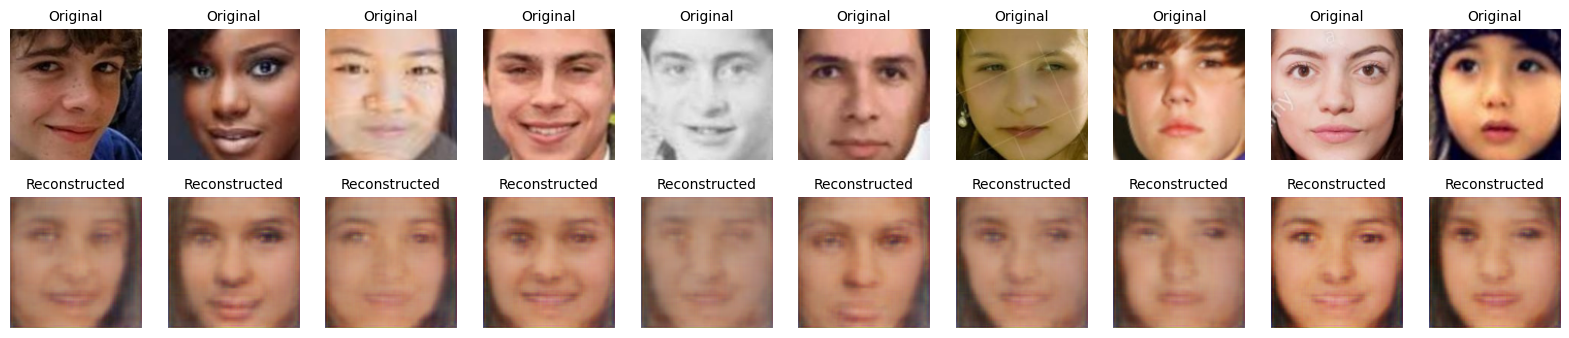

In [22]:
import matplotlib.pyplot as plt

n = 10

x_sample = tf.convert_to_tensor(x_test[:n], dtype=tf.float32)
# age_sample = tf.convert_to_tensor(x_test_ages[:n], dtype=tf.float32)
# age_sample = tf.convert_to_tensor([1,1,1,1,1,1,1,1,1,1], dtype=tf.float32)
age_sample = tf.convert_to_tensor([2, 2, 2, 2, 2, 2, 2, 2, 2, 2], dtype=tf.float32)

z_mean, z_log_var, z = vae.encoder([x_sample, age_sample], training=False)
decoded_imgs, _ = vae.decoder([z, age_sample], training=False)

plt.figure(figsize=(20, 4))
for i in range(n):
    # Imagen original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_sample[i].numpy())
    plt.axis("off")
    plt.title("Original", fontsize=10)

    # Imagen reconstruida
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].numpy())
    plt.axis("off")
    plt.title("Reconstructed", fontsize=10)

plt.show()


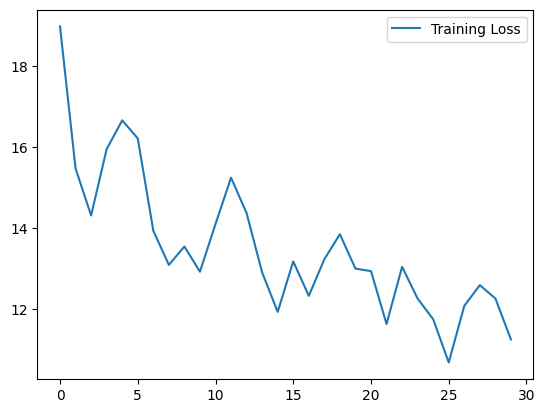

In [23]:
loss = history.history['loss']

epoch_range = range(epochs)

plt.plot(epoch_range, loss, label='Training Loss')
plt.legend()
plt.show()

In [24]:
def generate_age_variations(img_path, ages=[5, 15, 25, 40, 60, 80]):
    """
    Genera múltiples versiones de una imagen con diferentes edades.
    Requiere:
        - vae: modelo entrenado
        - preprocess_image: debe devolver recortes faciales normalizados [0,1]
    """

    # --- Preprocesamiento ---
    face_crops = preprocess_image(img_path)
    if len(face_crops) == 0:
        raise ValueError("No se detectó ninguna cara en la imagen.")

    face = face_crops[0]

    # Batch de tamaño 1
    face_batch = np.expand_dims(face, axis=0)
    face_tensor = tf.convert_to_tensor(face_batch, dtype=tf.float32)

    decoded_results = []

    # --- Procesar cada edad ---
    for age_value in ages:
        age_tensor = tf.convert_to_tensor([[age_value]], dtype=tf.float32)

        # Encode + obtener skips
        enc_out = vae.encoder([face_tensor, age_tensor], training=False)
        z_mean, z_log_var, z = enc_out[:3]

        # Decode con skips
        decoded_img, _ = vae.decoder([z, age_tensor], training=False)

        decoded_results.append(decoded_img[0].numpy())

    # --- Mostrar ---
    plt.figure(figsize=(3 * len(ages), 4))

    # Mostrar imagen original
    plt.subplot(1, len(ages) + 1, 1)
    plt.imshow(face)
    plt.title("Original")
    plt.axis("off")

    # Mostrar variaciones
    for i, age_value in enumerate(ages):
        plt.subplot(1, len(ages) + 1, i + 2)
        plt.imshow(decoded_results[i])
        plt.title(f"Edad: {age_value}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

    return decoded_results

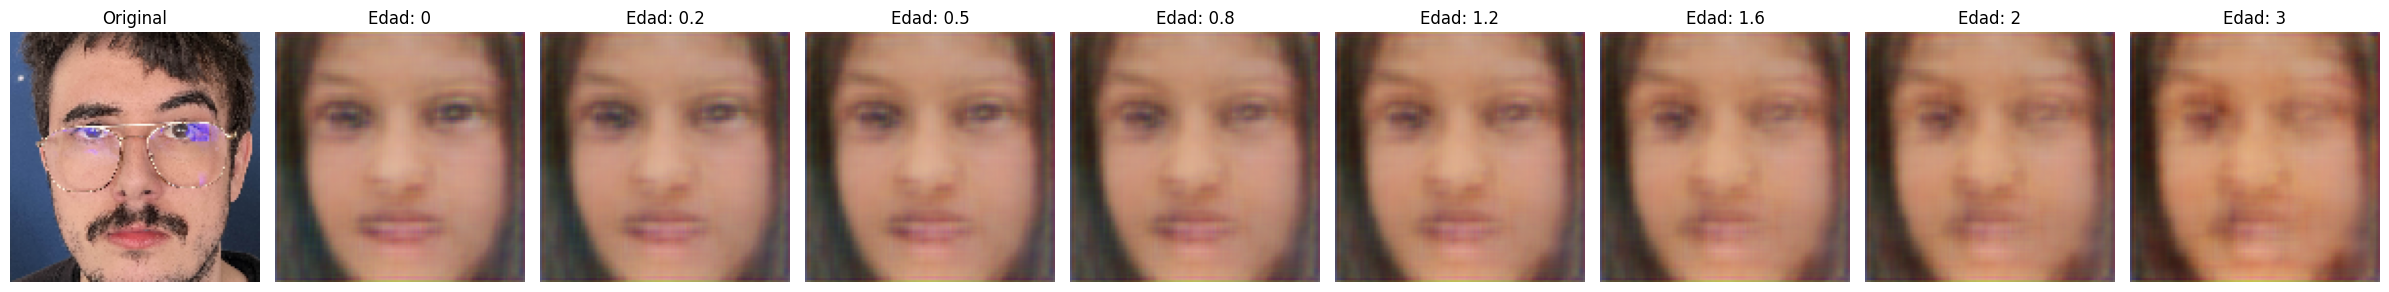

[array([[[0.52955955, 0.36152652, 0.2935887 ],
         [0.4519693 , 0.26300567, 0.17337313],
         [0.4317415 , 0.27974176, 0.17034745],
         ...,
         [0.27333933, 0.19916119, 0.3838617 ],
         [0.30267477, 0.21445476, 0.3580845 ],
         [0.49681318, 0.20633182, 0.36409077]],
 
        [[0.44129822, 0.38864744, 0.32580516],
         [0.37697068, 0.24204947, 0.1723279 ],
         [0.3955662 , 0.23624855, 0.20605916],
         ...,
         [0.29007298, 0.18119195, 0.3405476 ],
         [0.31814796, 0.20205942, 0.25885156],
         [0.46510893, 0.14183408, 0.25592622]],
 
        [[0.4075968 , 0.324583  , 0.39457324],
         [0.3728403 , 0.24473576, 0.2092079 ],
         [0.39139414, 0.2664416 , 0.23748975],
         ...,
         [0.3012323 , 0.25481877, 0.226565  ],
         [0.36071366, 0.2765146 , 0.18159302],
         [0.44654202, 0.1553207 , 0.20815349]],
 
        ...,
 
        [[0.33258328, 0.35857144, 0.47037408],
         [0.3232493 , 0.3044447 , 0.31094

In [30]:
generate_age_variations(
    img_path="../Images/M.jpg",
    # ages=[0, -5, -2 ,-1, 1, 2, 5]
    ages=[0, 0.2, 0.5, 0.8, 1.2, 1.6, 2, 3]
)